# 1. Сформулировать содержательную постановку задачи

#### Цель исследования:

Провести кластерный анализ футболистов на основе их ключевых характеристик для выявления стратегически значимых групп игроков с целью оптимизации трансферной политики футбольных клубов.

#### Задачи исследования:
- Выделить однородные группы футболистов по комплексу признаков.
- Определить игроков с высокой рыночной стоимостью и потенциалом для формирования конкурентной команды.  
- Выявить молодых перспективных игроков, которые могут быть приобретены для долгосрочного развития.  
- Предложить рекомендации для клубов по стратегии покупки или продажи игроков. 



# 2. Загрузка данных

### Перечень используемых библиотек
- Pandas — Работа с табличными данными (датафреймами)

- NumPy — Работа с массивами и матрицами, математические операции

- Matplotlib —  Визуализация данных (графики, диаграммы)

- MinMaxScaler - Нормализация данных – преобразует признаки к заданному диапазону (по умолчанию [0, 1]).

- RobustScaler - Нормализует данные, используя медиану и межквартильный размах (IQR), что делает метод устойчивым к выбросам.

- cdist — Вычисление расстояний между объектами (евклидово расстояние).

- PCA — Снижение размерности данных (например, с 9 признаков до 2 для визуализации).

- Seaborn (sns) - Статистическая визуализация поверх Matplotlib

- pairwise_distances - Функция вычисляет матрицу расстояний на основе векторного массива X и, опционально, Y

- calinski_harabasz_score - вычисляет индекс Калински-Харабаса, также известный как критерий отношения дисперсии. Этот показатель представляет собой отношение суммы дисперсии между кластерами и дисперсии внутри кластеров (где дисперсия определяется как сумма квадратов расстояний).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.metrics import pairwise_distances
from sklearn.metrics import calinski_harabasz_score

### Кратко про датасет

Датасет был взят из платформы Kagle - [Football Player Statistics](https://www.kaggle.com/datasets/yorkyong/football-player-statistics)
 
По заявлению автора, дата сет содержи статистику по примерно 3000 футболистов, собранную с сайта SoFIFA.com с помощью парсинга (автоматического извлечения данных) через библиотеку Beautiful Soup в Python. SoFIFA.com – Популярный сайт с детальной статистикой игроков FIFA (как в игре, так и в реальной жизни). Датасет содержит 64 атрибута.

### Работа

Для начала продемонстрирую визуально датасет на примере 5 записей. 


In [3]:
path = 'C:\\Users\\e617k\\Desktop\\Пиитон экзамен\\players_stats.csv'

# Загрузка данных из CSV-файла в DataFrame
df = pd.read_csv(path)

# Убираю ограничение на количество столбцов
pd.set_option('display.max_columns', None)
df.head(5)

,name,Age,Overall rating,Potential,Team & Contract,ID,Height,Weight,foot,Best overall,Best position,Growth,Value,Wage,Release clause,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total movement,Acceleration,Sprint speed,Agility,Reactions,Balance,Total power,Shot power,Jumping,Stamina,Strength,Long shots,Total mentality,Aggression,Interceptions,Att. Position,Vision,Penalties,Composure,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Unnamed: 64
0,15 Ronaldinho CAM ST,34,78,78,Querétaro\n2014 ~ 2016,28130,"182cm / 6'0""",76kg / 168lbs,Right,77,CAM,0,€4.1M,€45K,€0,367,84,69,50,82,82,430,86,86,87,81,90,313,50,48,73,70,72,314,74,55,41,72,72,319,60,25,66,82,86,0,78,25,28,25,54,7,14,13,6,14,1875,377,3,49,72,83,84,28,NaN
1,O. Hutchinson RM CAM,19,65,81,Ipswich Town\n2022 ~ 2025,260145,"174cm / 5'9""",65kg / 143lbs,Left,67,CAM,16,€1.8M,€3K,€4.5M,266,48,53,49,66,50,304,69,52,50,65,68,366,76,69,81,61,79,272,62,56,63,47,44,264,41,37,60,65,61,63,140,40,49,51,39,10,7,9,5,8,1651,351,1,72,54,61,70,44,NaN
2,Brahim CAM,23,82,86,Real Madrid\n2019 ~ 2027,231410,"170cm / 5'7""",68kg / 150lbs,Right,84,CAM,4,€43.5M,€145K,€92.4M,328,75,76,30,83,64,379,84,74,61,75,85,429,85,85,89,79,91,332,73,60,68,55,76,294,44,33,78,81,58,79,84,40,23,21,51,13,9,13,10,6,1897,409,1,85,74,78,85,31,NaN
3,K. Wätjen CM,17,62,80,Borussia Dortmund\n2024 ~ 2028,70728,"178cm / 5'10""",72kg / 159lbs,Right,65,CAM,18,€1M,€900,€2.3M,257,48,53,45,67,44,292,66,52,43,65,66,356,77,68,78,59,74,267,48,58,63,51,47,263,47,54,54,59,49,49,161,50,55,56,48,9,13,7,11,8,1644,353,1,72,50,59,66,52,NaN
4,A. Güler CAM RM,18,77,88,Real Madrid\n2023 ~ 2029,264309,"175cm / 5'9""",70kg / 154lbs,Left,79,CAM,11,€22M,€41K,€49.5M,340,80,68,41,81,70,403,83,84,76,79,81,380,75,69,82,69,85,308,72,50,70,43,73,316,42,55,68,80,71,77,155,52,57,46,58,13,10,11,14,10,1960,405,1,72,70,80,81,52,NaN


### Загрузка и фильтрация данных в датафрейм data_filtered

Данные загружаются в переменную df - таблица, датафрейм , после чего из него выбираются необходимые атрибуты для исследования и формируется новый датафрейм - data_filtered.

Сам исходный датасет players_stats.csv содрежит более 60 атрибутов, для своего исследования ПРЕДВАРИТЕЛЬНО я выделил основные признаки, соотвествующие цели исследования и обьяснил свой выбор: 

1. Value (рыночная стоимость игрока) — важный показатель, отражающий текущую ценность игрока. Это сумма, которую клуб может запросить за переход игрока. Отражает текущую ценность игрока. Кластеризация по этому признаку поможет выделить группы игроков с высокой, средней и низкой стоимостью, что может быть полезно для скаутов или менеджеров клубов. Он напрямую связан с целями исследования (выделение групп по стоимости) и является основным показателем для принятия решений о трансферах.

2. Potential (потенциал) — Потенциал показывает, насколько игрок может вырасти в будущем. Это важный показатель для скаутов и менеджеров, которые ищут молодых талантов для развития. Он дополняет рыночную стоимость, позволяя выделить не только текущую ценность игрока, но и его будущую перспективу.

3. Age (возраст) — это важный фактор, влияющий как на стоимость, так и на потенциал игрока. Молодые игроки обычно имеют больший потенциал роста, а зрелые игроки — высокий текущий уровень. Возраст помогает разделить игроков на группы по их жизненному циклу (молодые, зрелые, опытные), что важно для понимания их текущей и будущей стоимости.

4. Overall rating (общий рейтинг) — Текущий рейтинг отражает уровень игрока на данный момент. Это важный показатель для формирования состава команды и оценки текущей ценности игрока. Рейтинг помогает выделить игроков с высоким, средним и низким уровнем мастерства, что важно для понимания их текущей стоимости.

5. Wage (зарплата) — отражает зарплату игрока. Это важный показатель для финансового планирования и оценки доступности игрока.

6. Release clause (отступные) — сумма, которую нужно заплатить за переход игрока в другой клуб без согласия текущего клуба. Отступные помогают выделить игроков, которых можно легко или сложно приобрести. Он связан с рыночной стоимостью, так как игроки с низкими отступными могут быть более доступны для трансфера.

7. International reputation (международная репутация) — Репутация отражает известность игрока на международной арене. Это может влиять на его стоимость и популярность. Репутация помогает выделить звездных игроков, которые могут быть переоценены из-за своей известности.  Он дополняет рыночную стоимость, так как известные игроки часто имеют более высокую стоимость, даже если их текущий уровень не соответствует ей.

8. Total stats (общие статистические показатели) — суммарная характеристика игрока, основанная на его статистике (например, голы, передачи, отборы мяча и т.д.). Отражает вклад игрока в команду. Общая статистика помогает выделить группы игроков с разным уровнем мастерства.

9. Growth (рост) — показывает, насколько игрок может улучшиться. Полезен для выделения игроков с высоким потенциалом роста. 

10. Total Movement (Общая подвижность) - Интегральный показатель физической готовности. Составные компоненты: Acceleration (ускорение), Sprint speed (скорость), Agility (ловкость), Reactions (реакция), Balance (баланс) 

11. Total Power (Общая сила) - Определяет физическое доминирование в единоборства, при стандартных положениях, в концовках матчей. Компоненты: Shot power (сила удара), Jumping (прыгучесть), Stamina (выносливость), Strength (физическая сила), Long shots (дальние удары)

12. Total Mentality (Ментальные качества) - Показывает "интеллектуальную" составляющую:Лидерские качества (капитаны обычно ≥80), Тактическую дисциплину, Способность принимать решения под давлением Составляющие: Aggression (агрессивность), Interceptions (перехваты), Positioning (позиционирование), Vision (видение поля), Composure (хладнокровие)

13. Total Skill (Технические навыки) - Компоненты: Dribbling (дриблинг), Curve (крученые), FK Accuracy (штрафные), Ball control (контроль), Long passing (длинные передачи)

14. Total Defending (Оборонные навыки) - Совокупность защитных качеств: отборы, подкаты, позиционная игра.

15. Total Goalkeeping (Вратарские навыки) - Специфические вратарские характеристики: реакция, ловля, игра на выходах.

16. Total Attacking (Общая атака) - Комплексный показатель атакующих качеств игрока, включающий: Crossing (навесы) Finishing (завершение атак) Heading Accuracy (игра головой) Short Passing (короткие передачи) Volleys (удары с лета)

И также 3 атрибута для индификации объекта в таблице - это наименование футболиста, его идентификатор и контракт, а также любимую позицию игрока на поле

*Важно отметить, что я использую только общие метрики, которые предоставляют суммарные показатели по более мелким. Все они обозначены как «Total».

In [4]:
selected_columns = [
    "ID",
    "name",
    'Team & Contract',
    "Age",
    'Best position',
    "Value", 
    "Potential",
    "Overall rating",
    "Wage",
    "Release clause",
    "International reputation",
    "Total stats",
    "Growth",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total skill",
    "Total defending",
    "Total goalkeeping",
    "Total attacking"
]
data_filtered = df[selected_columns]
data_filtered.head(5)

,ID,name,Team & Contract,Age,Best position,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking
0,28130,15 Ronaldinho CAM ST,Querétaro\n2014 ~ 2016,34,CAM,€4.1M,78,78,€45K,€0,3,1875,0,313,314,319,430,78,54,367
1,260145,O. Hutchinson RM CAM,Ipswich Town\n2022 ~ 2025,19,CAM,€1.8M,81,65,€3K,€4.5M,1,1651,16,366,272,264,304,140,39,266
2,231410,Brahim CAM,Real Madrid\n2019 ~ 2027,23,CAM,€43.5M,86,82,€145K,€92.4M,1,1897,4,429,332,294,379,84,51,328
3,70728,K. Wätjen CM,Borussia Dortmund\n2024 ~ 2028,17,CAM,€1M,80,62,€900,€2.3M,1,1644,18,356,267,263,292,161,48,257
4,264309,A. Güler CAM RM,Real Madrid\n2023 ~ 2029,18,CAM,€22M,88,77,€41K,€49.5M,1,1960,11,380,308,316,403,155,58,340


# 3. Обработка данных
Для начала выведу общую статиску по атрибутам с помощью функции info().

Количество non-Null значений для каждого атрибута = 3120, следовательно отсуствующих значений нет.
Также, определю количество дубликатов с помощью 2-ух функций duplicated().sum(). Оно равно 371, что не есть хорошо, их также нужно будет очистить. Этим займусь в следующих действиях.

Ключевой момент анализа таблицы — такие важные признаки, как Value, Potential, Overall Rating, Wage и Release Clause, имеют тип object. Это означает, что данные хранятся в текстовом формате (например, '€100M'), хотя должны быть числовыми. Для дальнейшего анализа их необходимо очистить и преобразовать в числовой тип данных

In [5]:
# Общая информация о данных (типы столбцов, количество non-null значений)
print(data_filtered.info())
num_duplicates = data_filtered.duplicated().sum()
print(f"\nКоличество дубликатов: {num_duplicates}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   ID                        3120 non-null   int64 
 1   name                      3120 non-null   object
 2   Team & Contract           3120 non-null   object
 3   Age                       3120 non-null   int64 
 4   Best position             3120 non-null   object
 5   Value                     3120 non-null   object
 6   Potential                 3120 non-null   object
 7   Overall rating            3120 non-null   object
 8   Wage                      3120 non-null   object
 9   Release clause            3120 non-null   object
 10  International reputation  3120 non-null   int64 
 11  Total stats               3120 non-null   int64 
 12  Growth                    3120 non-null   int64 
 13  Total movement            3120 non-null   int64 
 14  Total power             

Чтобы понять в чем дело, с помощью функции .unique() выведу все возможноые значения атрибутов (Value, Potential, Overall Rating, Wage и Release Clause). 

В результатам анализа видно:
1. Для атрибутов Value, Wage, Release clause используется идентичный денежный формат, для которого требуется отдельная обработка
2. Для атрибутов Potential, Overall rating также используется одинаковый формат, где встречаются такие значения, как '87-1' или '79+2', для подобного формата также требуется индивидуальная обработка

In [6]:
# Я использую срезы - [:20] для только чтобы вывести только 20 возможных значений, иначе вывод сильно увеличится
print(
data_filtered['Value'].unique()[:20],
data_filtered['Potential'].unique()[:20],
data_filtered['Overall rating'].unique()[:20],
data_filtered['Wage'].unique()[:20],
data_filtered['Release clause'].unique()[:20],
data_filtered['Best position'].unique(),
sep = '\n\n'
)

['€4.1M' '€1.8M' '€43.5M' '€1M' '€22M' '€5M' '€22.5M' '€46M' '€128.5M'
 '€6M' '€52.5M' '€14.5M' '€39.5M' '€2.1M' '€3.3M' '€11.5M' '€45M' '€6.5M'
 '€31M' '€118.5M']

['78' '81' '86' '80' '88' '75' '87' '92' '87+1' '82' '87+3' '90' '89' '94'
 '82+1' '88+1' '85' '84' '87-1' '77']

['78' '65' '82' '62' '77' '74' '88' '83+1' '79+2' '66' '70' '80+1' '76'
 '82+1' '73' '87' '72' '89' '81' '75']

['€45K' '€3K' '€145K' '€900' '€41K' '€19K' '€18K' '€110K' '€230K' '€15K'
 '€130K' '€60K' '€76K' '€1K' '€5K' '€11K' '€49K' '€22K' '€550' '€82K']

['€0' '€4.5M' '€92.4M' '€2.3M' '€49.5M' '€9.9M' '€42.8M' '€88.6M'
 '€273.1M' '€12.6M' '€103.7M' '€24.7M' '€83M' '€5.3M' '€89.2M' '€22.7M'
 '€93.4M' '€13.2M' '€65.1M' '€210.3M']

['CAM' 'ST' 'LWB' 'CB' 'CM' 'RM' 'CDM' 'LM' 'RB' 'RWB' 'LB' 'LW' 'GK' 'CF'
 'RW']


Для обработки пункта 1 я создал функцию convert_value, а для пункта 2 calculate_potential.

Я добавил признак "Best position" для предварительной группировки игроков на 4 категории:

- Атакующие (Attacking) – ST, CF, LW, RW

- Полузащитники (Midfield) – CM, CDM, LM, RM, CAM

- Защитники (Defense) – CB, RB, LB, LWB, RWB

- Вратари (Goalkeeper) – GK

Причина:

- Разные позиции требуют разных навыков (например, вратари оцениваются по другим критериям, чем нападающие).

- Кластеризация по отдельным группам повышает точность, так как игроки одной роли имеют схожие характеристики.

*В дальнейшем данный атрибут будет использоваться для фильтрации данных перед кластеризацией

In [7]:
# Функция для преобразования значений
def convert_value(value):
    # Удаляем символ валюты (€)
    value = value.replace('€', '')
    
    # Если значение содержит 'M' (миллионы)
    if 'M' in value:
        return float(value.replace('M', '')) * 1_000_000
    # Если значение содержит 'K' (тысячи)
    elif 'K' in value:
        return float(value.replace('K', '')) * 1_000 
    # Если значение просто число (например, '0')
    else:
        return float(value)
    
def calculate_potential(value):
    # Если есть модификатор (например, '87-2', '81+3')
    if '-' in value or '+' in value:
        # Разделяем основное число и модификатор
        main_value = int(''.join(filter(str.isdigit, value.split('-')[0].split('+')[0])))
        modifier = value.replace(str(main_value), '')  # Извлекаем модификатор
        # Вычисляем итоговый потенциал
        if '-' in modifier:
            return main_value - int(modifier.replace('-', ''))
        elif '+' in modifier:
            return main_value + int(modifier.replace('+', ''))
    # Если модификатора нет, возвращаем основное число
    return int(value)

def group_positions(position):
    attacking = ['ST', 'CF', 'LW', 'RW']
    midfield = ['CM', 'CDM', 'RM', 'LM','CAM']
    defense = ['CB', 'RB', 'LB', 'LWB', 'RWB']
    
    if position in attacking:
        return 'Attacking'
    elif position in midfield:
        return 'Midfield'
    elif position in defense:
        return 'Defense'
    elif position == 'GK':
        return 'Goalkeeper'
    else:
        return 'Other'  # На случай, если появятся новые позиции

Теперь применим функционал к атрибутам для обработки и удалим дубликаты с помощью встренной функции drop_duplicates()

In [8]:
# Применяем функцию к столбцу 'Value'
data_filtered['Value'] = data_filtered['Value'].apply(convert_value)
data_filtered['Wage'] = data_filtered['Wage'].apply(convert_value)
data_filtered['Release clause'] = data_filtered['Release clause'].apply(convert_value)

# Применяем функцию к столбцу 'Potential'
data_filtered['Potential'] = data_filtered['Potential'].apply(calculate_potential)
data_filtered['Overall rating'] = data_filtered['Overall rating'].apply(calculate_potential)


# Добавляем столбец с группой
data_filtered['Position group'] = data_filtered['Best position'].apply(group_positions)


# Удаление дубликатов
data_filtered = data_filtered.drop_duplicates()

C:\Users\e617k\AppData\Local\Temp\ipykernel_20460\1988569986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['Value'] = data_filtered['Value'].apply(convert_value)
C:\Users\e617k\AppData\Local\Temp\ipykernel_20460\1988569986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['Wage'] = data_filtered['Wage'].apply(convert_value)
C:\Users\e617k\AppData\Local\Temp\ipykernel_20460\1988569986.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

Для проверки результатов еще раз воспользуюсь функцией info() и посчитаю количество дубликатов. В результате данные обработаны и очищены, можно переходить к следующему этапу

In [9]:
data_filtered.info()

num_duplicates = data_filtered.duplicated().sum()
print(f"\nКоличество дубликатов: {num_duplicates}")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2749 entries, 0 to 3111
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2749 non-null   int64  
 1   name                      2749 non-null   object 
 2   Team & Contract           2749 non-null   object 
 3   Age                       2749 non-null   int64  
 4   Best position             2749 non-null   object 
 5   Value                     2749 non-null   float64
 6   Potential                 2749 non-null   int64  
 7   Overall rating            2749 non-null   int64  
 8   Wage                      2749 non-null   float64
 9   Release clause            2749 non-null   float64
 10  International reputation  2749 non-null   int64  
 11  Total stats               2749 non-null   int64  
 12  Growth                    2749 non-null   int64  
 13  Total movement            2749 non-null   int64  
 14  Total po

Я построил корреляционную матрицу для выбранных признаков (feat), чтобы:

- Выявить сильно коррелирующие пары признаков.

- Уменьшить мультиколлинеарность — зависимость между предикторами, которая может искажать результаты кластеризации.

- Упростить модель, оставив только информативные и независимые признаки.

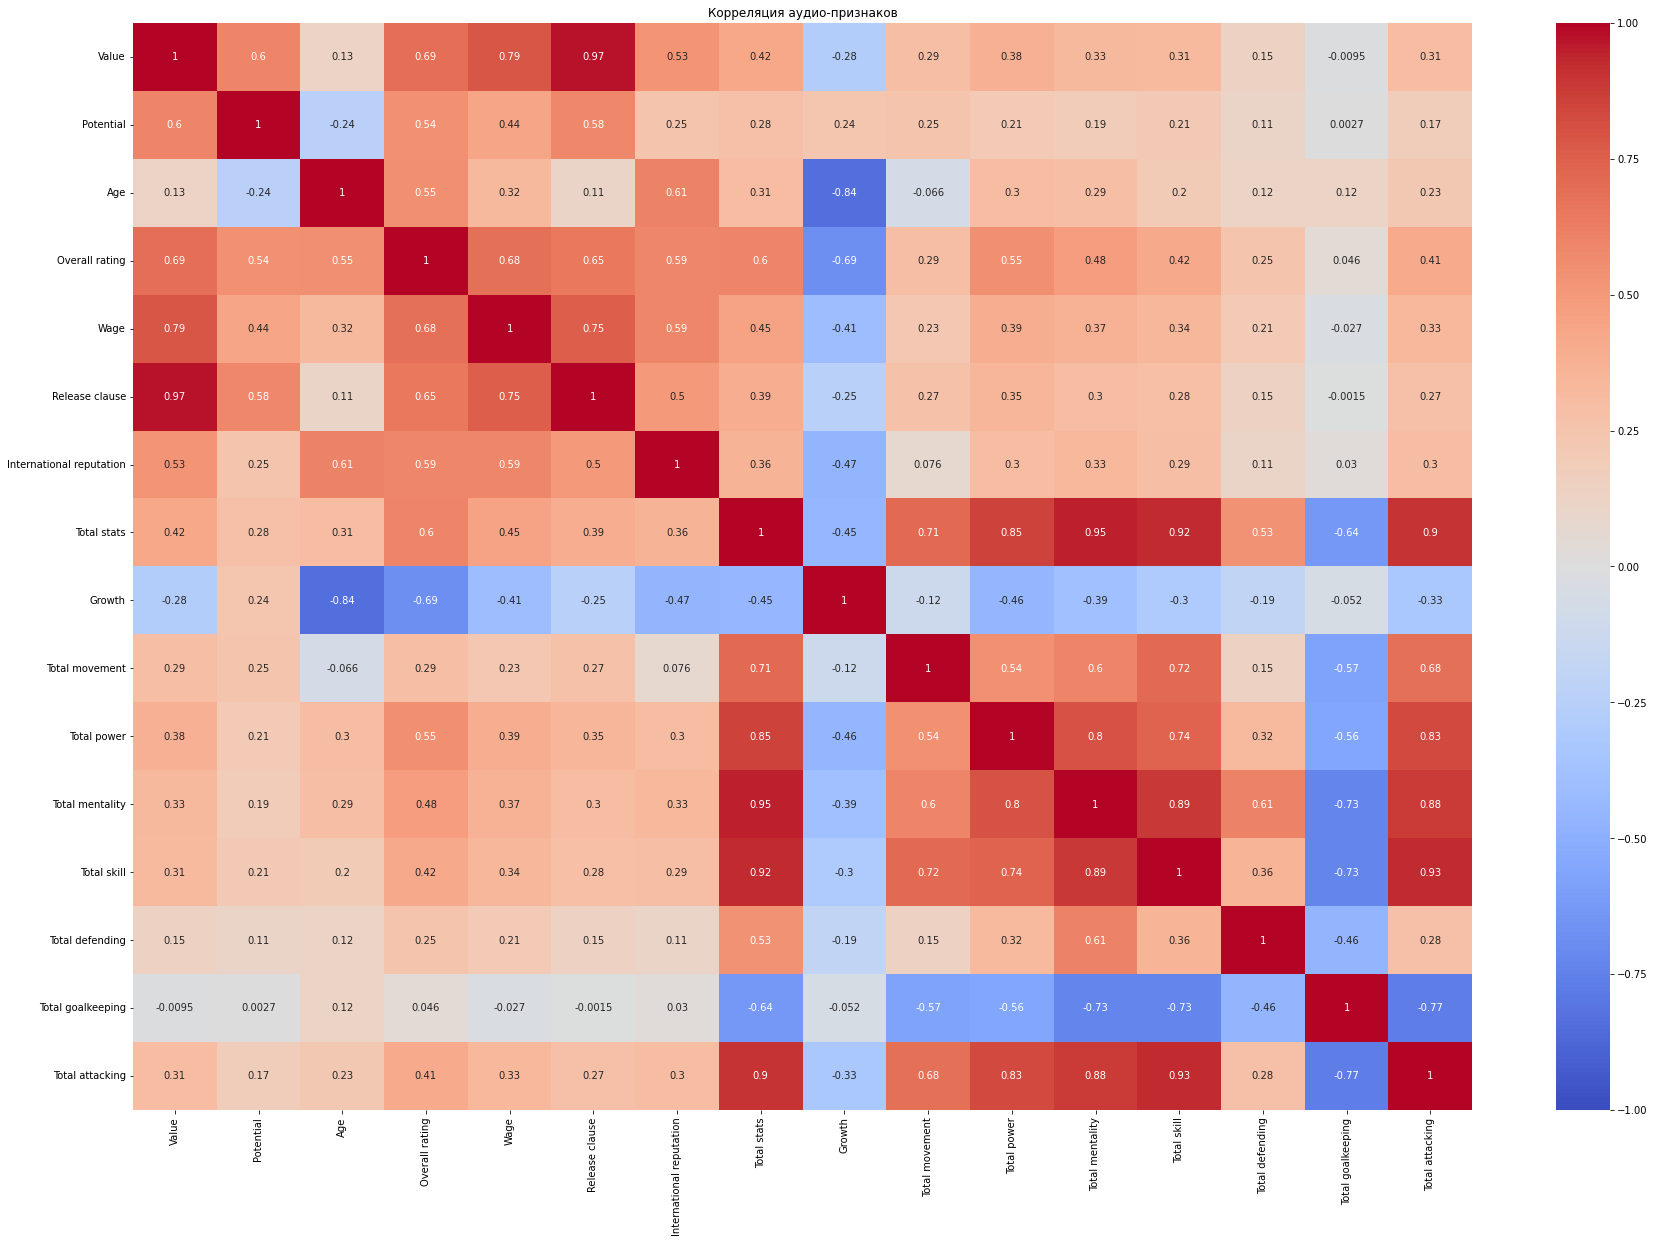

In [ ]:
feat = [
    "Value", 
    "Potential",
    "Age",
    "Overall rating",
    "Wage",
    "Release clause",
    "International reputation",
    "Total stats",
    "Growth",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total skill",
    "Total defending",
    "Total goalkeeping",
    "Total attacking"
]

# Вычисляем корреляции
corr = data_filtered[feat].corr()
# Визуализация
plt.figure(figsize=(30, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция')
plt.show()

На основе анализа корреляционной матрицы были удалены следующие признаки:

1. Release clause (Сумма отступных), где чрезвычайно высокая корреляция с Value (0.97) → практически дублирует информацию о рыночной стоимости игрока.


2. Total stats (Общая статистика) - Сильная корреляция с: Total mentality (0.95) Total skill (0.92) Total attacking (0.90) → Является агрегированным показателем, "поглощающим" информацию других признаков. Признак избыточен — его составляющие (например, атакующие/защитные навыки) уже учтены отдельно.

3. Total power (Физическая мощь) - Высокая корреляция с: Total stats (0.85) Total mentality (0.80) Total attacking (0.83) → Физические показатели частично дублируются в других признаках (например, скорость учтена в Total movement). Появляется риск перевеса физических атрибутов над техническими в кластеризации.

4. Total skill (Технические навыки) - Почти полная корреляция с Total attacking (0.93) → навыки дриблинга, ударов и контроля мяча уже учтены в атакующих показателях. Для позиций, где навыки критичны (например, нападающие), важен Total attacking, а не обобщенный Total skill.

### Стандартизация\Нормализация данных

Для начала с помощью функции .describe() рассмотрбю основные характеристики ЧИСЛЕННЫХ атрибутов.

Для числовых столбцов (int, float) по умолчанию выводятся:
- count	-> Количество непустых (не-NaN) значений
- mean	-> Среднее значение
- std	-> Стандартное отклонение (мера разброса данных)
- min	-> Минимальное значение
- 25%	-> Первый квартиль (25% данных ниже этого значения)
- 50%	-> Медиана (второй квартиль)
- 75%	-> Третий квартиль (75% данных ниже этого значения)
- max	-> Максимальное значение

In [11]:
# Для удобства использования запишу признаки в переменну feat
feat = [
    "Value", 
    "Potential",
    "Age",
    "Overall rating",
    "Wage",
    "International reputation",
    "Growth",
    "Total movement",
    "Total mentality",
    "Total defending",
    "Total goalkeeping",
    "Total attacking"
]

data_filtered[feat].describe()

,Value,Potential,Age,Overall rating,Wage,International reputation,Growth,Total movement,Total mentality,Total defending,Total goalkeeping,Total attacking
count,2.749000e+03,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000
mean,1.112710e+07,79.025464,24.184794,73.149145,29842.269916,1.443798,5.909785,349.095671,293.264096,156.205529,71.749000,291.698072
std,1.647762e+07,4.956955,4.840322,6.611788,37940.053451,0.795861,5.719410,52.221458,62.726504,64.900077,78.738232,71.329900
min,0.000000e+00,54.000000,16.000000,47.000000,0.000000,1.000000,0.000000,133.000000,72.000000,24.000000,13.000000,51.000000
25%,2.000000e+06,76.000000,20.000000,69.000000,5000.000000,1.000000,0.000000,324.000000,268.000000,97.000000,46.000000,267.000000
50%,4.900000e+06,80.000000,23.000000,74.000000,17000.000000,1.000000,5.000000,359.000000,303.000000,175.000000,51.000000,303.000000
75%,1.400000e+07,82.000000,27.000000,78.000000,39000.000000,2.000000,10.000000,385.000000,334.000000,213.000000,57.000000,338.000000
max,1.850000e+08,94.000000,44.000000,91.000000,350000.000000,5.000000,25.000000,462.000000,417.000000,269.000000,433.000000,440.000000


Общие наблюдения из describe():

1. Сильный разброс значений (особенно в Value, Wage, Release clause): Например, Value: от 0 до 185 млн (стандартное отклонение ≈ 16.5 млн). Это может доминировать при использовании евклидова расстояния. 

2. Категориальные признаки: International reputation (1-5) — уже числовой, но дискретный. 

3. Особенности для "Total"-метрик (например, Total attacking, Total defending). Диапазоны разные: Total goalkeeping (13-433) vs Total defending (24-269). 

4. Общие приблемы:
- Нулевые значения в Value, Wage, Release clause (возможно, пропуски или игроки без контракта).
- Выбросы (например, Release clause max=356 млн при 75%-квантиле=24.2 млн).

В рамках своего исследования я буду использовать комбинацию из трех методов предобработки данных: стандартизацию, логарифмирование и MinMax-нормализацию. Такой подход корректен и обоснован для обобщенного алгоритма Форэль, поскольку:

- Алгоритм использует единый радиус для всех признаков → требует соразмерного вклада каждого признака

- Логарифм сжимает шкалу финансовых показателей (исключает доминирование абсолютных значений)

- MinMax приводит все признаки к единому диапазону [0,1]

А в работе с межкластерными расстояниями мой подходи похволит сохарнить относительные расстояния между точками, а это в свою очередь гарантирует , что ни один признак не будет доминировать из-за исходного масштаба, разной дисперсии, разных диапазонов.

Подытожим:

Для финансовых показтелей буду использовать Логарифмирование + RobustScaler (Нормализует данные, используя медиану и межквартильный размах (IQR)), так как такие атрибуты имеют сильную правостороннюю асимметрию (большой хвост больших значений). Это касается атрибутов:
- Value
- Wage

Для обычных числовых признаков буду использовать Стандартизация RobustScaler (Нормализует данные, используя медиану и межквартильный размах (IQR))
- Age
- Overall rating
- Potential
- Growth

Для общих метрик буду использовать MinMax [0,1] (Нормализует данные в фиксированный диапазон [0, 1])
- International reputation
- Total movement
- Total mentality  
- Total defending  
- Total goalkeeping  
- Total attacking

Формулы:

- Формула RobustScaler: $\dfrac{x_i – Q_1(x)}{Q_3(x) – Q_1(x)}$, где Q1 — 1-й квартиль, Q3 — 3-й квартиль
- Формула MinMaxScaler: $X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))$, где min и max — минимальное и максимальное допустимое значение, по умолчанию min=0, max=1.

Проверю данные и удостоверюсь, что цена не указана у свободных агентов. По атрибуту "Team & Contract" видно, что это действительно так.

In [12]:
free_agents_count = len(data_filtered[data_filtered['Value'] == 0])
print(f"Количество свободных агентов (Value=0): {free_agents_count}")

data_filtered[(data_filtered['Value'] == 0) ].head(5)

Количество свободных агентов (Value=0): 74


,ID,name,Team & Contract,Age,Best position,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking,Position group
184,252008,I. Reyes CB CDM,Mexico\nFree,23,CDM,0.0,81,74,0.0,0.0,1,2061,7,395,375,354,348,225,45,319,Midfield
263,244973,M. Ruiz CM CAM CDM,Mexico\nFree,22,CM,0.0,82,75,0.0,0.0,1,2012,7,370,360,345,365,199,49,324,Midfield
291,246289,C. Huerta LW LM,Mexico\nFree,22,RM,0.0,81,75,0.0,0.0,1,1918,6,385,354,283,333,161,48,354,Midfield
308,234579,J. Quiñones CF ST LW,Mexico\nFree,26,ST,0.0,79,78,0.0,0.0,1,1987,1,396,422,315,345,99,51,359,Attacking
341,235537,E. Sánchez CM CDM,Mexico\nFree,23,CM,0.0,83,78,0.0,0.0,1,2109,5,372,390,369,361,223,55,339,Midfield


Принимаю решение не включать в анализ свободных агентов по следующим причинам:
- Анализ ориентирован на поиск платных трансферов для клуба, а не на подписание свободных агентов. Эти сценарии требуют разных стратегий скаутинга и бюджетного планирования.
- Нулевые значения создают искусственный пик в распределении стоимости, нарушая нормальность данных

In [13]:
data_filtered = data_filtered[data_filtered['Value'] != 0]

#### Приведение данных к нужному виду

In [14]:
features = [
    "Value", 
    "Potential",
    "Age",
    "Overall rating",
    "Wage",
    "International reputation",
    "Growth",
    "Total movement",
    "Total mentality",
    "Total defending",
    "Total goalkeeping",
    "Total attacking",
    "Position group"
]

# Копирую данные в новый датафрейм - data_preprocessed
data_preprocessed = data_filtered.copy()

# -----------------------------------------------------------------------------------
# Раздельная обработка признаков

# Финансовые показатели (логарифмируем + RobustScaler)
# Логарифмируем финансовые показатели
financial_features = ["Value", "Wage"]
for col in financial_features:
    data_preprocessed[f"{col}"] = np.log1p(data_preprocessed[col])
    
# Применяем RobustScaler
robust_scaler = RobustScaler()
scaled_financial = robust_scaler.fit_transform(data_preprocessed[["Value", "Wage"]])

# Создаем новые столбцы в data_preprocessed с Зарплатой и Ценой футболистов
data_preprocessed["Value"] = scaled_financial[:, 0]
data_preprocessed["Wage"] = scaled_financial[:, 1]

# Рейтинги и потенциал (только RobustScaler)
rating_features = ["Potential", "Overall rating", "Age", "Growth"]
data_preprocessed[rating_features] = robust_scaler.fit_transform(data_preprocessed[rating_features])

# Возраст и рост (MinMaxScaler)
minmax_features = ["Age", "Growth"]
data_preprocessed[minmax_features] = MinMaxScaler().fit_transform(data_preprocessed[minmax_features])

# Игровые характеристики и Международный рейтинг - применяю MinMaxScaler
total_stats_features = [
    "International reputation",
    "Total movement",
    "Total mentality", 
    "Total defending",
    "Total goalkeeping",
    "Total attacking"
]
data_preprocessed[total_stats_features] = MinMaxScaler(feature_range=(0, 1)).fit_transform(data_preprocessed[total_stats_features])

# 3. Формируем финальный набор признаков для FOREL
feat = [
    "Value",
    "Wage",
    "Potential",
    "Overall rating",
    "International reputation",
    "Age",
    "Growth",
    "Total movement",
    "Total mentality",
    "Total defending",
    "Total goalkeeping",
    "Total attacking",
]

# Проверяем результат
data_preprocessed.describe()


,ID,Age,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking
count,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2.675000e+03,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000
mean,237793.524486,0.288972,0.038340,-0.146729,-0.092960,-0.128510,2.033041e+07,0.110841,1798.756262,0.239626,0.657524,328.801121,0.642010,307.120000,0.541388,0.138838,0.619703
std,36509.333501,0.171380,0.675190,0.819593,0.737915,0.763073,3.236921e+07,0.197342,255.929587,0.230098,0.157806,50.106424,0.180848,73.712008,0.264818,0.185960,0.182183
min,41.000000,0.000000,-2.345470,-4.333333,-3.000000,-1.888043,0.000000e+00,0.000000,843.000000,0.000000,0.000000,146.000000,0.000000,61.000000,0.000000,0.000000,0.000000
25%,224405.500000,0.142857,-0.435374,-0.666667,-0.555556,-0.579079,2.600000e+06,0.000000,1670.500000,0.000000,0.583587,299.000000,0.568116,280.000000,0.302041,0.078571,0.555270
50%,243576.000000,0.250000,0.000000,0.000000,0.000000,0.000000,8.200000e+06,0.000000,1837.000000,0.200000,0.686930,335.000000,0.669565,320.000000,0.620408,0.090476,0.647815
75%,262650.500000,0.392857,0.564626,0.333333,0.444444,0.420921,2.480000e+07,0.250000,1974.000000,0.400000,0.765957,366.000000,0.759420,356.000000,0.771429,0.104762,0.740360
max,279922.000000,1.000000,1.914904,2.333333,1.888889,1.564335,3.561000e+08,1.000000,2330.000000,1.000000,1.000000,442.000000,1.000000,465.000000,1.000000,1.000000,1.000000


In [15]:
print(f"Общая статиска по количеству игроков по их позициям:\n {data_preprocessed['Position group'].value_counts()}")

Общая статиска по количеству игроков по их позициям:
 Midfield      1202
Defense        776
Attacking      521
Goalkeeper     176
Name: Position group, dtype: int64


### Сформирую матрицы «объект-признак», «объект-объект»

##### Матрица «объект-признак»

In [16]:
# Создаю список, содержащий названия столбцов, которые отображают признаки датафрейма data_filtered и добавлю traIDck_id для идертификации строки 
column_sel = [
    "ID",
    "Value",
    "Wage",
    "Potential",
    "Overall rating",
    "International reputation",
    "Age",
    "Growth",
    "Total movement",
    "Total mentality",
    "Total defending",
    "Total goalkeeping",
    "Total attacking"
]
# Из датафрейма data_filtered выбираю только столбцы, перечисленные в переменной column_sel для построения матрицы объект-признак и вывожу первые 10 строк
print("Матрица объект-признак:")
data_filtered[column_sel].head(10)

Матрица объект-признак:


,ID,Value,Wage,Potential,Overall rating,International reputation,Age,Growth,Total movement,Total mentality,Total defending,Total goalkeeping,Total attacking
0,28130,4100000.0,45000.0,78,78,3,34,0,313,319,78,54,367
1,260145,1800000.0,3000.0,81,65,1,19,16,366,264,140,39,266
2,231410,43500000.0,145000.0,86,82,1,23,4,429,294,84,51,328
3,70728,1000000.0,900.0,80,62,1,17,18,356,263,161,48,257
4,264309,22000000.0,41000.0,88,77,1,18,11,380,316,155,58,340
5,225667,5000000.0,19000.0,75,74,1,26,1,417,322,131,65,358
6,240833,22500000.0,18000.0,87,77,2,18,10,409,281,86,60,343
7,235790,46000000.0,110000.0,87,82,3,24,5,382,347,133,47,404
8,252371,128500000.0,230000.0,92,88,4,20,4,411,406,233,48,385
9,246685,6000000.0,15000.0,80,74,1,23,6,378,316,203,51,296


*Важно: я использую исходные данные (не нормализованные), для более понятного отображения. И в дальнейшем буду использовать матрицу в интерпритации результатов кластерного анализа

##### «объект-объект»

Для расстония я использую манхэттенское расстояние, так как она менее чувствительна к выбросам в данных (например, к игрокам с аномально высокой стоимостью). И она хорошо применима для смешанных данных, как в моем случае

In [17]:
# Создаю матрицу, куда записываю уже ПОДГОТОВЛЕННЫЕ данные признаков
data = data_preprocessed[feat].values

# Матрица "объект-объект" с евклидовым расстоянием
# С помощью функции pairwise_distances вычисляю попарные расстояния (манхэттенское расстояние) между объектами в массиве data
distance_matrix = pairwise_distances(
    data_preprocessed[feat],
    metric='manhattan'  # Для смешанных данных
)
# Преобразую матрицу расстояний в датафрейм с помощью функции pd.DataFrame
distance_matrix_df = pd.DataFrame(distance_matrix, index=data_preprocessed.index, columns=data_preprocessed.index)
# Вывожу таблицу объект-объект c матрицей попарных растояний
print("Матрица объект-объект:")
pd.set_option('display.max_columns', None)
distance_matrix_df

Матрица объект-объект:


0         1         2         3         4         5         6     \
0     0.000000  6.353036  5.256843  7.677034  4.834789  2.920366  4.728989   
1     6.353036  0.000000  7.773269  1.760980  5.931510  5.022953  5.791179   
2     5.256843  7.773269  0.000000  9.491392  2.924869  5.587829  3.006830   
3     7.677034  1.760980  9.491392  0.000000  7.455755  6.407742  7.437872   
4     4.834789  5.931510  2.924869  7.455755  0.000000  4.667612  1.386223   
...        ...       ...       ...       ...       ...       ...       ...   
3107  4.756035  4.318911  7.344449  4.579460  6.951444  2.594949  6.167587   
3108  4.071371  3.654572  6.838720  4.831459  5.578405  1.760371  5.683421   
3109  5.277642  1.962468  6.095351  3.478767  4.168825  3.977955  4.255290   
3110  6.266875  1.445457  8.690249  1.677266  6.692709  5.239933  6.744391   
3111  5.922768  2.392280  8.627399  3.414130  7.264144  3.872321  7.166261   

           7          8         9          10        11        12        13    \
0      4.882023   8.284586  3.597807   5.551655  2.612845  5.709113  6.921423   
1      8.316272  11.460740  3.746317   8.746856  7.137570  7.527588  1.472860   
2      1.619019   4.482607  5.002107   1.413437  3.608948  1.996035  8.198336   
3     10.039156  13.007434  4.959678  10.503074  8.684263  9.213057  1.658333   
4      2.964353   5.648277  3.596078   3.094937  3.780444  1.808872  6.117773   
...         ...        ...       ...        ...       ...       ...       ...   
3107   8.429762  11.703348  3.774785   8.443162  6.989722  8.182901  4.019531   
3108   7.218038  10.236927  2.246065   7.673384  5.641920  6.831939  4.024088   
3109   6.628417   9.547714  2.485673   7.092334  5.555156  5.788032  2.120376   
3110   9.252300  12.122618  4.060576   9.716217  7.817135  8.411915  2.226204   
3111   9.189449  12.045482  3.769155   9.653367  7.782856  8.571922  3.002357   

          14        15        16        17        18        19         20    \
0     5.168905  6.925702  2.871693  5.282682  7.662304  4.996430   6.791607   
1     2.114581  6.898423  4.842280  7.467233  4.239388  6.909270   9.916332   
2     6.794813  3.495722  3.499095  1.920078  6.750830  2.084526   3.616498   
3     3.315002  8.302260  6.535913  9.185355  4.412781  8.627392  11.544659   
4     5.096015  2.424812  2.520073  2.395439  4.139712  1.293870   4.093665   
...        ...       ...       ...       ...       ...       ...        ...   
3107  3.545548  7.747171  5.119295  6.981634  4.484425  7.396463  10.238940   
3108  2.176548  6.197468  4.037775  6.335665  5.122392  6.574058   8.980683   
3109  1.202692  5.037778  3.819169  5.755568  3.281551  5.207129   8.114871   
3110  2.547440  7.526968  5.713031  8.360403  5.242580  7.831012  10.714945   
3111  2.598743  7.775546  5.738587  8.316601  5.583937  8.302447  10.890190   

          21        22         23        24        25        26        27    \
0     5.976294  4.905179   8.483660  4.196373  4.783893  5.038506  5.376779   
1     3.173893  5.953095  12.185936  6.169896  7.577489  5.040470  3.867806   
2     5.557140  2.975655   4.621238  1.925707  2.185292  3.576508  4.974171   
3     4.577730  7.593992  13.946916  7.888018  9.295611  6.687164  5.343071   
4     3.393968  1.035174   6.538779  1.553309  2.070029  1.389972  2.477665   
...        ...       ...        ...       ...       ...       ...       ...   
3107  4.735076  6.555402  11.901741  6.335022  7.827444  5.775356  5.436040   
3108  3.234621  6.103888  11.291843  5.649964  6.997640  5.190103  3.648631   
3109  1.633219  4.515758  10.536176  4.515167  5.942842  3.521973  2.181447   
3110  3.821485  7.023906  13.160059  7.104268  8.531943  6.030121  4.524922   
3111  4.375778  7.482381  13.168637  7.175454  8.517333  6.655552  5.159215   

          28        29        30         31         32        33        34    \
0     4.538301  3.389352  6.498119   6.029181   4.401489  5.424925  7.407702   
1     7.189550  7.154231  5.495876  10.344

# 4. Описание и работа алгоритма для обобщенного алгоритма Форэль

Алгоритм реализован в виде функции forel_step1. Также в моем датасете будут как 

#### 1. Подготовка и входные данные
Алгоритм принимает на вход:
- Предобработанный датасет с характеристиками футболистов - Сам датафрейм с футболистами
- Радиус R (основной параметр, определяющий размер кластеров) - Математический (технический) параметр (Определяет максимальное расстояние между точкой и центром кластера, чтобы точка была включена в этот кластер. Чем больше R, тем более широкие кластеры будут формироваться. Меньшее значение R приведет к более компактным кластерам.)
- Минимальное количество игроков min_points для формирования кластера - Пользовательский (бизнес-ориентированный) параметр (Определяет минимальное количество футболистов, необходимых для формирования кластера. Это позволяет отсеять небольшие, нерепрезентативные группы.)
- Целевую позицию для анализа (атака, полузащита, защита, вратари) - Пользовательский (бизнес-ориентированный) параметр (Указывает, игроков какой позиции нужно кластеризовать. Это позволяет анализировать нападающих, полузащитников, защитников или вратарей отдельно.)
- Максимальное число итераций max_iter (по умолчанию 100) - Математический (технический) параметр (Ограничивает количество итераций, которые алгоритм будет выполнять при поиске и уточнении кластеров. Это нужно для предотвращения бесконечных циклов, если алгоритм не может сойтись.)

#### 2. Фильтрация данных по позициям
Алгоритм начинает с фильтрации игроков:
- Для атакующих ("Attacking") выбираются: ST, CF, LW, RW, CAM
- Для полузащитников ("Midfield"): CM, CDM, LM, RM
- Для защитников ("Defense"): CB, RB, LB, LWB, RWB
- Для вратарей ("GK"): только GK

#### 3. Инициализация рабочих данных
После фильтрации:
- Выбираются только значимые признаки (feat) для анализа
- Создается рабочая копия данных (X) и сохраняется оригинал (X_origin)
- Инициализируются пустые списки для кластеров и их центров

#### 4. Основной цикл кластеризации
Алгоритм итеративно ищет кластеры, пока в оставшихся данных X есть точки и количество итераций не превысит максимальное значение max_iter.

4.1 Выбор начального центра - На каждой итерации выбирается точка из X, которая будет считаться потенциальным центром кластера. Выбор происходит не случайно, а на основе количества соседей в радиусе R. Для каждой точки рассчитывается количество других точек в X, находящихся на расстоянии меньше R (используется манхэттенское расстояние или по другому cityblock). Точка с наибольшим числом соседей выбирается в качестве начального центра.

4.2 Итеративное уточнение центра кластера: Далее начинается внутренний цикл, который пытается уточнить положение центра кластера.

- Определение точек в кластере: Вычисляются расстояния от текущего центра до всех точек в X. Точки, находящиеся на расстоянии не более R от центра, считаются принадлежащими текущему кластеру.
- Проверка размера кластера: Если количество точек в кластере меньше, чем min_points, кластер считается незначимым, и внутренний цикл прерывается. Это означает, что выбранный начальный центр не подходит для формирования достаточно большого кластера.
- Пересчет центра кластера: Если кластер содержит достаточно точек, вычисляется новый центр кластера как среднее арифметическое координат всех точек, принадлежащих кластеру.
- Проверка сходимости: Сравнивается новый центр с предыдущим. Если центры практически совпадают (изменение меньше заданной погрешности, проверяется с помощью np.allclose), это означает, что центр кластера стабилизировался, и внутренний цикл прерывается. В противном случае, текущий центр обновляется новым значением, и внутренний цикл продолжается. Предусмотрена возможность прерывания внутреннего цикла по достижении максимального числа итераций max_iter.

4.3 Сохранение кластера: Если в конечном итоге кластер содержит не менее min_points точек, то найденные точки (in_cluster) добавляются в список clusters, а центр кластера (center) – в список centers.

4.4 Удаление кластеризованных точек: После того, как кластер сформирован, точки, вошедшие в этот кластер, удаляются из X, чтобы их не учитывали при поиске следующих кластеров. Удаление происходит на основании расстояния до последнего уточненного центра.

Инкремент счетчика итераций: Счетчик внешних итераций iteration увеличивается на 1.

#### 5. Возврат результатов: 

После завершения основного цикла алгоритм возвращает:

- clusters: Список, содержащий массивы точек, представляющих каждый найденный кластер.
- centers: Массив координат центров найденных кластеров.
- X_origin: Исходный массив признаков, полученный из выбранного подмножества данных.
- bet.index: Индексы соответствующих строк в исходном DataFrame data_preprocessed. Это позволяет соотнести найденные кластеры с конкретными футболистами.


In [18]:
def forel_step1(data_preprocessed, R, min_points, position, max_iter=100):
    # Выбираем подмножество данных в зависимости от указанной позиции.
    if position == 'Attacking':
        bet = data_preprocessed[data_preprocessed['Position group'] == 'Attacking']
    elif position == 'Midfield':
        bet = data_preprocessed[data_preprocessed['Position group'] == 'Midfield']
    elif position == 'Defense':
        bet = data_preprocessed[data_preprocessed['Position group'] == 'Defense']
    elif position == 'GK':
        bet = data_preprocessed[data_preprocessed['Position group'] == 'GK']

    # Если ни одна из позиций не совпала, будет ошибка.
    # Извлекаем признаки (столбцы, по которым будем кластеризовать) из отфильтрованного DataFrame.
    df_5 = bet[feat]
    # Сохраняем исходные данные признаков для дальнейшего использования.
    X_origin = df_5.values
    # Копируем данные признаков в переменную X, с которой будет работать алгоритм.
    # Это нужно, чтобы не изменять исходные данные напрямую.
    X = df_5.values # Создаем копию массива NumPy.
    
    # Инициализируем списки для хранения кластеров и их центров.
    clusters = [] # Список для хранения массивов NumPy, представляющих кластеры.
    centers = [] # Список для хранения центров кластеров.
    iteration = 0  # Счетчик итераций
    while len(X) > 0 and iteration < max_iter:
        # Выбираем случайный объект как центр
        distances = cdist(X, X, metric='cityblock')  # Матрица расстояний между всеми точками
        neighbor_counts = np.sum(distances < R, axis=1) - 1  # Количество соседей для каждой точки (исключая саму точку)
        max_neighbor_index = np.argmax(neighbor_counts)  # Индекс точки с наибольшим количеством соседей
        center = X[max_neighbor_index]
        inner_iteration = 0  # Счетчик внутренних итераций
        while True:
            # Находим объекты в радиусе R
            distances = cdist([center], X)[0]
            in_cluster = X[distances <= R]
            # Проверяем, достаточно ли точек в кластере
            if len(in_cluster) < min_points:
                break  # Недостаточно точек, пропускаем эту точку
            # Пересчитываем центр
            new_center = np.mean(in_cluster, axis=0)
            if np.allclose(center, new_center):
                break
            center = new_center
            inner_iteration += 1
            if inner_iteration >= max_iter:
                break  # Прерываем внутренний цикл, если слишком много итераций
        # Если кластер содержит достаточно точек, сохраняем его
        if len(in_cluster) >= min_points:
            clusters.append(in_cluster)
            centers.append(center)
            # Удаляем объекты из X
            X = X[distances > R]
        iteration += 1
    return clusters, np.array(centers), X_origin, bet.index 

##### Важно: дальнеший анализ будет проводиться по позиции Midfield, если необходимо анализировать другие позиции, то нужно изменить параметр функции

Далее я нахожу R - радиус для моего метода по следующему алгоритму:

- Вычисляю матрицу манхэттенских расстояний между всеми парами объектов в данных.
- Нахожу медиану этих расстояний.
- Делю медиану на 3 (или другое число, например от 2 до 5) – это и есть R.

In [19]:
position = 'Midfield'

midfielders = data_preprocessed[data_preprocessed['Position group'] == 'Midfield']


# Вычисляем матрицу расстояний для стандартизированных данных
distance_matrix = pairwise_distances(
    midfielders[feat],
    metric='manhattan'  # Для смешанных данных
)

# Рассчитываем медиану попарных расстояний
median_distance = np.median(distance_matrix[np.triu_indices_from(distance_matrix, k=1)])

# Эмпирическая формула для R
R = median_distance / 4  # Начальное значение (можно варьировать 2-5)

print(f"Медиана расстояний: {median_distance:.2f}")
print(f"Рекомендуемый R: {R:.2f}")

Медиана расстояний: 4.14
Рекомендуемый R: 1.04


Почему я выбрал R = 1.13?

Я запустил свой алгоритм , где R = median_distance / от 2 до 5 и получил следующие результаты:

- R = 2.07 = median_distance / 2 -> Критерий качества данных Calinski-Harabasz Score: 365.12 | Кол-во кластеров: 9 | Шум: 6
- R = 1.38 = median_distance / 3 -> Критерий качества данных Calinski-Harabasz Score: 417.97 | Кол-во кластеров: 6 | Шум: 27
- R = 1.04 = median_distance / 4 -> Критерий качества данных Calinski-Harabasz Score: 479.18 | Кол-во кластеров: 8 | Шум: 94
- R = 0.83 = median_distance / 5 -> Критерий качества данных Calinski-Harabasz Score: 465.82 | Кол-во кластеров: 11 | Шум: 167


Вывод:
R = 1.04 (делитель 4). Он дает хороший компромисс:
- Наивысший Calinski-Harabasz Score (479.18) – значит, кластеры хорошо разделены.
- Разумное количество кластеров (8).
- В разу меньше шума, чем при R = 0.83.


In [20]:
# Параметры
R = 1.04
min_points = 10
position = 'Midfield'

# Запуск алгоритма
clusters, centers, X, original_indices = forel_step1(data_preprocessed, R, min_points, position)

# Результаты
print("Кластеры:", len(clusters),'\n')
i = 0
sum_cluser = 0
for cluster in clusters:
   i += 1
   sum_cluser += len(cluster)
   print(f'Cluser {i}','  Количество точек в кластере = ',len(cluster))

print(f'\nКоличество футболистов на позиции {position} всего - {len(X)}')
print(f'Количество футбоилстов во всех кластерах всего - {sum_cluser}')
#print("\nЦентры кластеров:", len(centers))
# print(centers)

Кластеры: 8 

Cluser 1   Количество точек в кластере =  468
Cluser 2   Количество точек в кластере =  170
Cluser 3   Количество точек в кластере =  183
Cluser 4   Количество точек в кластере =  154
Cluser 5   Количество точек в кластере =  38
Cluser 6   Количество точек в кластере =  23
Cluser 7   Количество точек в кластере =  37
Cluser 8   Количество точек в кластере =  35

Количество футболистов на позиции Midfield всего - 1202
Количество футбоилстов во всех кластерах всего - 1108


# 5. Анализ результатов


Вычисление индекса Калински-Харабаса

In [21]:
# Сохраняем исходные данные
X_original = X
total_points = len(X_original)


# Создаём метки для исходных данных
labels = -np.ones(total_points)  # -1 = шум

for cluster_id, cluster in enumerate(clusters):
    # Для каждой точки в кластере находим её индекс в исходных данных
    for point in cluster:
        # Находим индекс точки в исходном массиве
        idx = np.where((X_original == point).all(axis=1))[0]
        if len(idx) > 0:
            labels[idx[0]] = cluster_id

# Подсчёт
points_in_clusters = np.sum(labels != -1)
noise_points = total_points - points_in_clusters

# Вычисляем индекс
if len(np.unique(labels[labels != -1])) > 1:
    ch_score = calinski_harabasz_score(X_original[labels != -1], labels[labels != -1])
    print(f"Calinski-Harabasz Score: {ch_score:.2f}")
    print(f"Количество кластеров: {len(clusters)}")
    print(f"Точек в кластерах: {points_in_clusters}/{total_points}")
    print(f"Шумовых точек: {noise_points}")
else:
    print("Недостаточно кластеров для вычисления индекса")

Calinski-Harabasz Score: 479.18
Количество кластеров: 8
Точек в кластерах: 1108/1202
Шумовых точек: 94


Построю график, показывающий кластеры футболистов после кластеризации. Каждый кластер представлен своим цветом, а некластеризованные точки показаны черными крестиками 

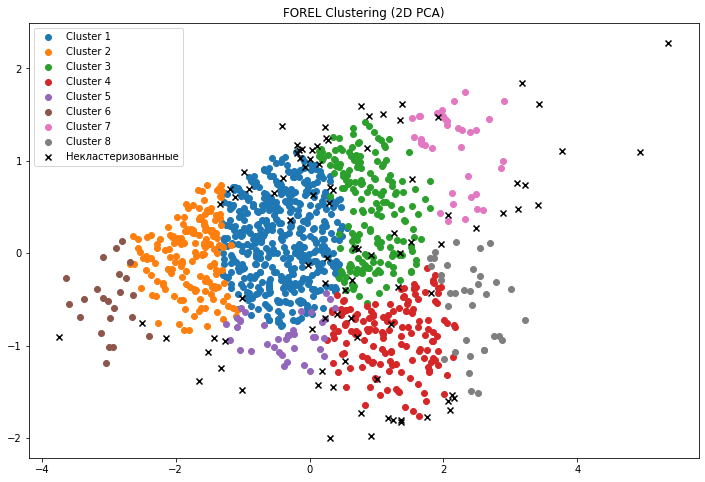

In [22]:
# Снижение размерности до 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(12, 8))  # Увеличиваем размер графика


# Визуализация кластеров
for i, cluster in enumerate(clusters):
    cluster_2d = pca.transform(cluster)
    plt.scatter(cluster_2d[:, 0], cluster_2d[:, 1], label=f"Cluster {i+1}")

# Визуализация некластеризованных точек
non_clustered_points = [point for point in X if not any((point == cluster_point).all() for cluster in clusters for cluster_point in cluster)]
non_clustered_2d = pca.transform(non_clustered_points)
plt.scatter(non_clustered_2d[:, 0], non_clustered_2d[:, 1], c='black', marker='x', label="Некластеризованные")

plt.legend()
plt.title("FOREL Clustering (2D PCA)")
plt.show()

Для анализа шума и остальных кластеров разедлю кластеры и некластеризованные точки(шум) в разные датафреймы

In [23]:
# Создаем маппинг индексов для оригинальных данных
index_mapping = {i: idx for i, idx in enumerate(original_indices)}

# Обработка кластеров
clustered_players = []
cluster_points_indices = set()

for i, cluster in enumerate(clusters):
    cluster_indices = []
    for point in cluster:
        # Находим индекс точки в X
        idx_in_origin = np.where((X == point).all(axis=1))[0][0]
        # Получаем соответствующий индекс в исходном DataFrame
        original_idx = index_mapping[idx_in_origin]
        cluster_indices.append(original_idx)
        cluster_points_indices.add(original_idx)
    
    players_in_cluster = data_filtered.loc[cluster_indices].copy()
    players_in_cluster['Cluster'] = i + 1
    clustered_players.append(players_in_cluster)

# Создаем DataFrame с кластеризованными игроками
if clustered_players:
    clustered_players_df = pd.concat(clustered_players)
else:
    clustered_players_df = pd.DataFrame(columns=data_filtered.columns.tolist() + ['Cluster'])

# Обработка шумовых точек (не попавших в кластеры)
all_indices = set(original_indices)
noise_indices = list(all_indices - cluster_points_indices)
noise_players_df = data_filtered.loc[noise_indices].copy()
noise_players_df['Cluster'] = -1  # Помечаем как шум


selected_columns_final_view = [
    "ID",
    "name",
    'Best position',
    "Value", 
    "Potential",
    "Age",
    "Overall rating",
    "Wage",
    "International reputation",
    "Growth",
    "Total movement",
    "Total mentality",
    "Total defending",
    "Total goalkeeping",
    "Total attacking",
    'Cluster'
]



##### Анализ некластеризованных точек

In [24]:
print('Количество объектов шума  =',noise_players_df['ID'].count())
# Вывожу первые 20 строчек в кластере 1
noise_players_df[selected_columns_final_view].head(30)
# noise_players_df.describe()


Количество объектов шума  = 94


,ID,name,Best position,Value,Potential,Age,Overall rating,Wage,International reputation,Growth,Total movement,Total mentality,Total defending,Total goalkeeping,Total attacking
1024,189242,Coutinho CAM LW,CAM,14500000.0,78,31,78,83000.0,4,0,381,338,152,48,357
3073,268599,Ó. Zambrano CDM CM,CM,3600000.0,83,19,70,500.0,1,13,336,321,201,52,269
2051,189157,Y. Bolasie LM LW,LM,750000.0,70,34,70,16000.0,2,0,355,306,80,49,317
4,264309,A. Güler CAM RM,CAM,22000000.0,88,18,77,41000.0,1,11,380,316,155,58,340
12,257534,C. Palmer RM RW CAM,CAM,39500000.0,90,21,81,76000.0,1,8,377,347,144,51,343
15,270673,W. Zaïre-Emery CM CDM,CM,43500000.0,90,17,81,11000.0,1,10,395,369,224,55,329
18,272978,J. Hato CB LB,CDM,6500000.0,88,17,73,550.0,1,15,395,294,216,40,270
23,238794,Vini Jr. LW ST,CAM,158500000.0,94,22,89,310000.0,5,5,454,323,75,36,373
1560,224574,O. Pineda CAM LM CM,RM,8000000.0,76,27,76,1000.0,1,0,406,355,195,56,350
2585,224739,23 P. Olayinka LM RM ST,LM,8000000.0,76,26,76,1000.0,1,0,387,353,195,55,357


In [25]:
noise_players_df.describe()

,ID,Age,Value,Potential,Overall rating,Wage,Release clause,International reputation,Total stats,Growth,Total movement,Total power,Total mentality,Total skill,Total defending,Total goalkeeping,Total attacking,Cluster
count,94.000000,94.000000,9.400000e+01,94.000000,94.000000,94.000000,9.400000e+01,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.0
mean,206958.138298,25.617021,8.412713e+06,77.755319,71.521277,22403.191489,1.548256e+07,1.776596,1844.765957,6.276596,347.510638,319.978723,311.531915,345.946809,153.117021,50.521277,316.159574,-1.0
std,78710.188027,7.215733,1.874772e+07,7.267080,8.105127,40101.681787,3.819110e+07,1.165400,195.259982,7.492511,47.080289,44.593017,46.042688,48.459132,51.400359,8.526655,45.500160,0.0
min,41.000000,16.000000,6.000000e+04,54.000000,47.000000,500.000000,0.000000e+00,1.000000,1209.000000,0.000000,220.000000,218.000000,196.000000,203.000000,43.000000,16.000000,197.000000,-1.0
25%,178770.750000,19.000000,1.050000e+06,74.000000,67.000000,900.000000,1.425000e+06,1.000000,1732.750000,0.000000,319.500000,281.250000,284.000000,312.000000,108.500000,46.000000,283.500000,-1.0
50%,234640.000000,24.500000,3.050000e+06,77.000000,73.500000,6000.000000,5.700000e+06,1.000000,1879.000000,3.000000,349.500000,325.000000,315.500000,354.500000,161.500000,52.000000,328.500000,-1.0
75%,269410.750000,33.000000,6.500000e+06,83.000000,77.000000,34750.000000,1.315000e+07,3.000000,1979.750000,10.750000,382.750000,353.750000,349.750000,377.750000,197.000000,56.000000,349.500000,-1.0
max,278207.000000,39.000000,1.585000e+08,94.000000,90.000000,310000.000000,3.368000e+08,5.000000,2166.000000,25.000000,454.000000,395.000000,405.000000,465.000000,245.000000,69.000000,409.000000,-1.0


“Шум” – это игроки, которых алгоритм кластеризации не смог отнести ни к одному из сформированных кластеров. Они не соответствуют критериям, чтобы быть частью какого-либо кластера, основываясь на заданных параметрах (R, min_points). Анализ этих игроков показывает, почему так произошло:

- Разнородность позиций: Многие из них - универсальные игроки, способные выступать на разных позициях, (CAM, CDM, CM, LW, RM, ST).

- Смешанные характеристики: У них нет четко выраженных сильных сторон, чтобы их можно было четко отнести к какому-либо стилю.

- Высокий потенциал/Возраст: Есть много молодых и перспективных игроков, которые еще не сформировали окончательные навыки, и опытных, но уже снизивших свои показатели.

- Выбросы по отдельным показателям: Некоторые игроки могут иметь экстремальные значения по отдельным характеристикам (например, очень высокую стоимость при относительно невысоком общем рейтинге), что делает их непохожими на остальных.

- Маленькая зарплата: Некоторые футболисты имеют очень маленькие зарплаты.

## Выгрузка данных для регрессии

In [29]:
clustered_players_df.to_csv('C:\\Users\\e617k\\Desktop\\Пиитон экзамен\\output.csv', index=False)  # index=False чтобы не записывать индекс DataFrame в файл

### Вывод результатов кластеров

Для более детального глубного анализа возможных трансферов я реализовал функцию **analyze_clusters**, позволяющую получить развернутый профиль каждого кластера. Она предоставляет информацию о размере кластера, финансовых показателях (средняя стоимость, зарплата, соотношение зарплаты к стоимости), ключевых характеристиках игроков (возраст, потенциал, общий рейтинг), позиционном составе, ключевых игровых показателях (атака, движение, защита, менталитет), уровне международной репутации и примерах игроков, демонстрируя типичных представителей каждого кластера. 

Обзор кластеров:

Кластер 6 (“Звезды”): Элитная группа из 23 игроков (медианный рейтинг 87, потенциал 90), таких как Де Брюйне и Гави. Они самые дорогие (€95 млн) и высокооплачиваемые (€180 тыс.), с выдающимися характеристиками (атака 86%, менталитет 91%) и высокой международной репутацией (91% ≥3).

Кластер 2 (“Крепкие игроки основы”): 170 игроков (медианный рейтинг 82, потенциал 84). Дорогие (€35 млн) и хорошо оплачиваемые (€80 тыс.), с хорошими характеристиками (атака 81%, менталитет 86%) и высокой международной репутацией (40% ≥3).

Кластер 1 (“Перспективная молодежь”): Самый большой кластер (468 игроков, медианный рейтинг 75, потенциал 80). Средние по стоимости (€10 млн) и зарплате (€29 тыс.), с акцентом на атаку и движение.

Кластер 5 (“Очень перспективные юноши”): Небольшой кластер (38 игроков, медианный рейтинг 73, потенциал 86) – молодые, перспективные игроки, но пока без международной известности.

Кластер 3 (“Игроки ротации”): Большой кластер (183 игрока, медианный рейтинг 70, потенциал 74). Недорогие (€2.5 млн) и низкооплачиваемые (€12 тыс.), представляют собой игроков ротации.

Кластер 4 (“Академия”): Молодые игроки из академии (154 игрока, медианный рейтинг 66, потенциал 81) с очень низкой зарплатой (€3 тыс.).

Кластер 7 (“Ветераны”): Возрастные игроки (37 игроков, медианный рейтинг 66, потенциал 68) с низкой стоимостью (€1 млн) и зарплатой (€4 тыс.).

Кластер 8 (“Воспитанники”): Самые молодые и низкооплачиваемые игроки (35 игроков, медианный рейтинг 60, потенциал 76), вероятно, только начинающие карьеру.

Рекомендации клубам:

- Поиск звезд: Кластер 6 - источник игроков высшего класса, но требуются значительные инвестиции.
- Усиление основы: Кластер 2 предлагает надежных игроков основы с хорошим соотношением цены и качества.
- Инвестиции в будущее: Кластеры 4 и 5 - источник молодых талантов, требующих развития, но с высоким потенциалом перепродажи.
- Экономия бюджета: Кластеры 3, 7 и 8 – недорогие варианты для ротации состава или комплектования молодежной команды.

Ниже представлена более детальная статисткиа

In [26]:
def analyze_clusters(clustered_players_df, full_dataset):
    # Проверка наличия обязательных столбцов
    required_cols = ['Cluster', 'Best position', 'Value', 'Wage', 'Potential', 'Age', 
                    'Overall rating', 'Total attacking', 'Total movement', 
                    'Total defending', 'Total mentality', 'Total goalkeeping',
                    'International reputation', 'name']
    
    missing_cols = [col for col in required_cols if col not in clustered_players_df.columns]
    if missing_cols:
        raise ValueError(f"Отсутствуют обязательные столбцы: {missing_cols}")

    # Создаем копии данных
    df = clustered_players_df.copy()
    full_df = full_dataset.copy()
    
    # Добавляем финансовый показатель
    df['Wage/Value_ratio'] = (df['Wage'] / df['Value']).replace([np.inf, -np.inf], np.nan) * 100
    
    # Группировка по кластерам и расчет статистики
    cluster_stats = df.groupby('Cluster').agg({
        'Potential': ['median', 'min', 'max'],
        'Age': ['median', 'min', 'max'],
        'Overall rating': ['median', 'min', 'max'],
        'Value': 'mean',
        'Wage': 'mean',
        'Wage/Value_ratio': 'mean',
        'Total attacking': 'median',
        'Total movement': 'median',
        'Total defending': 'median',
        'Total mentality': 'median',
        'Total goalkeeping': 'median',
        'Best position': lambda x: x.mode()[0] if not x.empty else 'Unknown',
        'International reputation': lambda x: (x >= 3).mean() * 100
    }).reset_index()
    
    # Переименовываем столбцы для удобства
    cluster_stats.columns = [
        'Cluster', 'Potential_median', 'Potential_min', 'Potential_max',
        'Age_median', 'Age_min', 'Age_max', 'Overall_rating_median',
        'Overall_rating_min', 'Overall_rating_max', 'Value_mean', 'Wage_mean',
        'Wage/Value_ratio_mean', 'Total_attacking_median', 'Total_movement_median',
        'Total_defending_median', 'Total_mentality_median', 'Total_goalkeeping_median',
        'Best_position', 'International_reputation'
    ]
    
    # Находим максимальные медианные значения среди всех кластеров
    max_attacking = cluster_stats['Total_attacking_median'].max()
    max_movement = cluster_stats['Total_movement_median'].max()
    max_defending = cluster_stats['Total_defending_median'].max()
    max_mentality = cluster_stats['Total_mentality_median'].max()
    max_goalkeeping = cluster_stats['Total_goalkeeping_median'].max()
    
    # Глобальные диапазоны значений
    global_ranges = {
        'attacking': (full_df['Total attacking'].min(), full_df['Total attacking'].max()),
        'movement': (full_df['Total movement'].min(), full_df['Total movement'].max()),
        'defending': (full_df['Total defending'].min(), full_df['Total defending'].max()),
        'mentality': (full_df['Total mentality'].min(), full_df['Total mentality'].max()),
        'goalkeeping': (full_df['Total goalkeeping'].min(), full_df['Total goalkeeping'].max())
    }
    
    # Анализ каждого кластера
    for _, row in cluster_stats.iterrows():
        cluster_id = row['Cluster']
        cluster_data = df[df['Cluster'] == cluster_id]
        total_players = len(cluster_data)
        best_position = row['Best_position']
        
        print(f"<<< Анализ кластера {cluster_id}: >>>")
        print(f"Размер кластера: {total_players} игроков")
        
        # Финансовые показатели
        print("\nФинансовые показатели:")
        print(f"- Средняя стоимость: €{row['Value_mean']:,.2f}")
        print(f"- Средняя зарплата: €{row['Wage_mean']:,.2f}")
        wage_value = row['Wage/Value_ratio_mean']
        print(f"- Соотношение зарплаты к стоимости: {wage_value:.2f}%") if not pd.isna(wage_value) else print("- Соотношение зарплаты к стоимости: Н/Д")
        
        # Основные характеристики
        print("\nОсновные характеристики:")
        print(f"- Возраст (медиана): {row['Age_median']:.1f} [мин: {row['Age_min']:.1f}, макс: {row['Age_max']:.1f}]")
        print(f"- Потенциал (медиана): {row['Potential_median']:.1f} [мин: {row['Potential_min']:.1f}, макс: {row['Potential_max']:.1f}]")
        print(f"- Общий рейтинг (медиана): {row['Overall_rating_median']:.1f} [мин: {row['Overall_rating_min']:.1f}, макс: {row['Overall_rating_max']:.1f}]")
        
        # Позиционный состав
        pos_counts = cluster_data['Best position'].value_counts()
        print("\nПозиционный состав:")
        for pos, count in pos_counts.items():
            percentage = (count / total_players * 100)
            print(f"- {pos}: {percentage:.1f}% ({count}/{total_players})")
        
        # Ключевые показатели
        print("\nКлючевые показатели:")
        if best_position == 'GK':
            # Для вратарей
            gk_percent = (row['Total_goalkeeping_median'] / max_goalkeeping) * 100
            move_percent = (row['Total_movement_median'] / max_movement) * 100
            ment_percent = (row['Total_mentality_median'] / max_mentality) * 100
            
            print(f"- Вратарское мастерство: {gk_percent:.1f}% | Медиана: {row['Total_goalkeeping_median']:.0f} [{global_ranges['goalkeeping'][0]:.0f}-{global_ranges['goalkeeping'][1]:.0f}]")
            print(f"- Движение: {move_percent:.1f}% | Медиана: {row['Total_movement_median']:.0f} [{global_ranges['movement'][0]:.0f}-{global_ranges['movement'][1]:.0f}]")
            print(f"- Менталитет: {ment_percent:.1f}% | Медиана: {row['Total_mentality_median']:.0f} [{global_ranges['mentality'][0]:.0f}-{global_ranges['mentality'][1]:.0f}]")
        else:
            # Для полевых игроков
            att_percent = (row['Total_attacking_median'] / global_ranges['attacking'][1]) * 100
            move_percent = (row['Total_movement_median'] / global_ranges['movement'][1]) * 100
            def_percent = (row['Total_defending_median'] / global_ranges['defending'][1]) * 100
            ment_percent = (row['Total_mentality_median'] / global_ranges['mentality'][1]) * 100
            
            print(f"- Атака: {att_percent:.1f}% (По медиане: {row['Total_attacking_median']:.0f})        | {global_ranges['attacking'][0]:.0f}-{global_ranges['attacking'][1]:.0f} (min-max)")
            print(f"- Движение: {move_percent:.1f}% (По медиане: {row['Total_movement_median']:.0f})     | {global_ranges['movement'][0]:.0f}-{global_ranges['movement'][1]:.0f} (min-max)")
            print(f"- Защита: {def_percent:.1f}% (По медиане: {row['Total_defending_median']:.0f})       | {global_ranges['defending'][0]:.0f}-{global_ranges['defending'][1]:.0f} (min-max)")
            print(f"- Менталитет: {ment_percent:.1f}% (По медиане: {row['Total_mentality_median']:.0f})   | {global_ranges['mentality'][0]:.0f}-{global_ranges['mentality'][1]:.0f} (min-max)")
        
        # Международная репутация
        print(f"\nМеждународная репутация (≥3): {row['International_reputation']:.1f}% игроков")
        
        # Примеры игроков (5 случайных)
        sample_size = min(5, len(cluster_data))
        examples = cluster_data[['name', 'Best position', 'Value', 'Wage', 'Overall rating', 'Potential', 'Age']].sample(sample_size)
        print("\nПримеры игроков:")
        print(examples.to_string(index=False, formatters={
            'Value': lambda x: f"€{x:,.2f}",
            'Wage': lambda x: f"{x:,.2f}",
            'Overall rating': lambda x: f"{x:.0f}",
            'Potential': lambda x: f"{x:.0f}",
            'Age': lambda x: f"{x:.0f}"
        }))
        
        print('\n' + '=' * 100 + '\n')

# Пример вызова
analyze_clusters(clustered_players_df, data_filtered)

<<< Анализ кластера 1: >>>
Размер кластера: 468 игроков

Финансовые показатели:
- Средняя стоимость: €10,324,786.32
- Средняя зарплата: €29,335.47
- Соотношение зарплаты к стоимости: 0.35%

Основные характеристики:
- Возраст (медиана): 23.0 [мин: 18.0, макс: 36.0]
- Потенциал (медиана): 80.0 [мин: 75.0, макс: 85.0]
- Общий рейтинг (медиана): 75.0 [мин: 69.0, макс: 82.0]

Позиционный состав:
- CAM: 42.5% (199/468)
- CM: 20.5% (96/468)
- CDM: 14.3% (67/468)
- RM: 13.2% (62/468)
- LM: 9.4% (44/468)

Ключевые показатели:
- Атака: 74.1% (По медиане: 326)        | 51-440 (min-max)
- Движение: 81.4% (По медиане: 376)     | 133-462 (min-max)
- Защита: 69.3% (По медиане: 186)       | 24-269 (min-max)
- Менталитет: 79.1% (По медиане: 330)   | 72-417 (min-max)

Международная репутация (≥3): 5.6% игроков

Примеры игроков:
                 name Best position          Value      Wage Overall rating Potential Age
  Y. Yazıcı CAM RM ST           CAM  €6,500,000.00 29,000.00             75        76  2